<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>

# Statistics for Data Science with Python
## Peer-Graded Assignment: Boston Housing Dataset Analysis

**Project Title:** Statistical Analysis of Boston Housing Dataset  
**Course:** ST0151EN - Statistics for Data Science with Python

#### Import the required libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

%matplotlib inline

#### Read the dataset from the URL

In [2]:
boston_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
boston_df = pd.read_csv(boston_url)

# Drop the unnecessary index column if present
if 'Unnamed: 0' in boston_df.columns:
    boston_df = boston_df.drop(columns=['Unnamed: 0'])

boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


---
## Task 1: Become familiar with the dataset

The following describes the dataset variables:

- **CRIM** - per capita crime rate by town  
- **ZN** - proportion of residential land zoned for lots over 25,000 sq.ft.  
- **INDUS** - proportion of non-retail business acres per town  
- **CHAS** - Charles River dummy variable (1 if tract bounds river; 0 otherwise)  
- **NOX** - nitric oxides concentration (parts per 10 million)  
- **RM** - average number of rooms per dwelling  
- **AGE** - proportion of owner-occupied units built prior to 1940  
- **DIS** - weighted distances to five Boston employment centres  
- **RAD** - index of accessibility to radial highways  
- **TAX** - full-value property-tax rate per $10,000  
- **PTRATIO** - pupil-teacher ratio by town  
- **LSTAT** - % lower status of the population  
- **MEDV** - Median value of owner-occupied homes in $1000's

In [3]:
print("Dataset shape:", boston_df.shape)
print("\nColumn names:", list(boston_df.columns))
print("\nData types:")
print(boston_df.dtypes)

Dataset shape: (506, 13)

Column names: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']

Data types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
LSTAT      float64
MEDV       float64
dtype: object


In [4]:
boston_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


---
## Task 2: Generate Descriptive Statistics and Visualizations

### 2.1 For the "Median value of owner-occupied homes" provide a boxplot

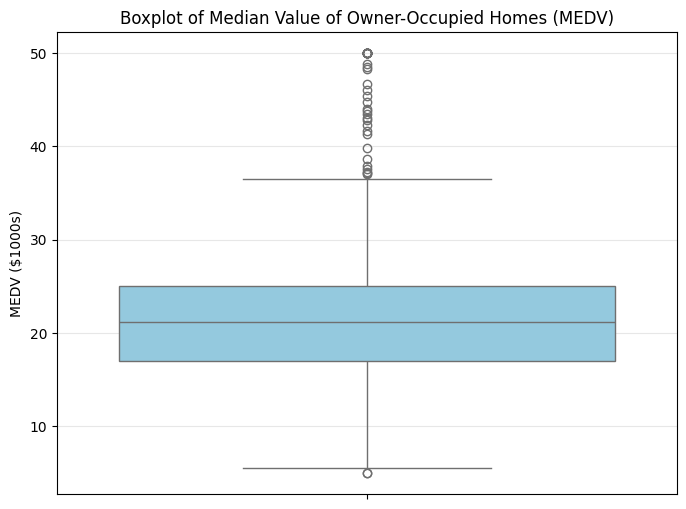


Interpretation: The boxplot shows the distribution of median home values.
Median MEDV: 21.20
There are outliers above the upper whisker (values > ~37).


In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=boston_df['MEDV'], color='skyblue')
plt.title('Boxplot of Median Value of Owner-Occupied Homes (MEDV)')
plt.ylabel('MEDV ($1000s)')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\nInterpretation: The boxplot shows the distribution of median home values.")
print(f"Median MEDV: {boston_df['MEDV'].median():.2f}")
print(f"There are outliers above the upper whisker (values > ~37).")

### 2.2 Provide a bar plot for the Charles river variable

/tmp/ipykernel_3618/115181807.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='CHAS', data=boston_df, palette='Set2')


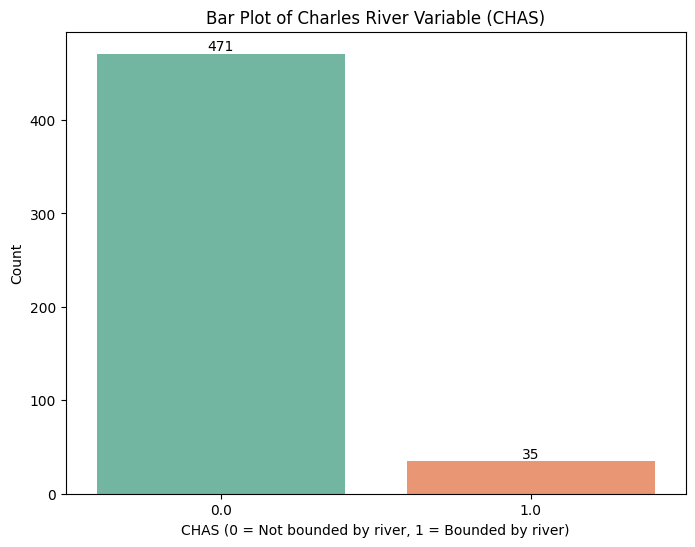


Interpretation: Most tracts (CHAS=0) are not bounded by the Charles River.
CHAS
0.0    471
1.0     35
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='CHAS', data=boston_df, palette='Set2')
plt.title('Bar Plot of Charles River Variable (CHAS)')
plt.xlabel('CHAS (0 = Not bounded by river, 1 = Bounded by river)')
plt.ylabel('Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

print("\nInterpretation: Most tracts (CHAS=0) are not bounded by the Charles River.")
print(boston_df['CHAS'].value_counts())

### 2.3 Provide a boxplot for the MEDV variable vs the AGE variable
(Discretize the age variable into three groups of 35 years and younger, between 35 and 70 years and 70 years and older)

/tmp/ipykernel_3618/2753655179.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AGE_group', y='MEDV', data=boston_df,


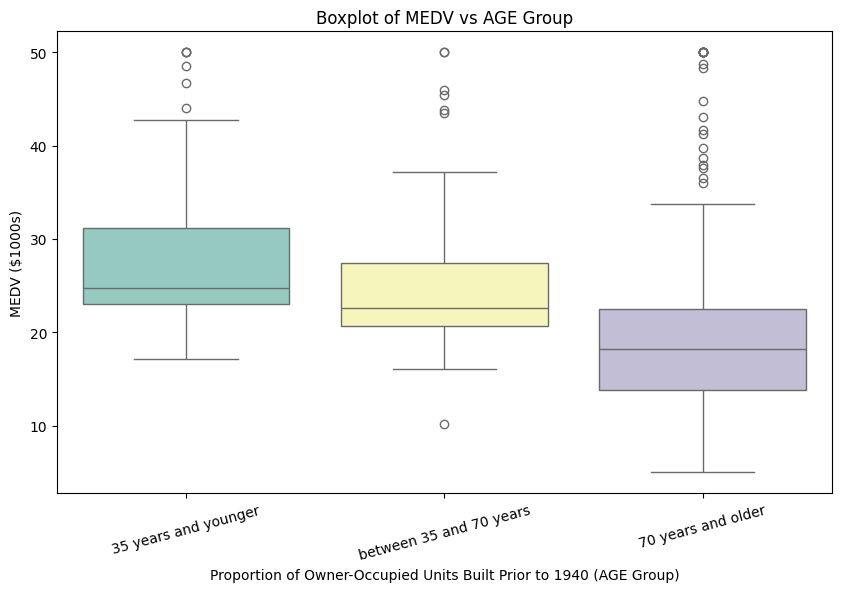


Interpretation: Homes in areas with a higher proportion of older buildings (70+ years)
tend to have lower median values compared to newer areas.


In [7]:
# Discretize AGE into three groups
boston_df.loc[boston_df['AGE'] <= 35, 'AGE_group'] = '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35) & (boston_df['AGE'] < 70), 'AGE_group'] = 'between 35 and 70 years'
boston_df.loc[boston_df['AGE'] >= 70, 'AGE_group'] = '70 years and older'

plt.figure(figsize=(10, 6))
sns.boxplot(x='AGE_group', y='MEDV', data=boston_df,
            order=['35 years and younger', 'between 35 and 70 years', '70 years and older'],
            palette='Set3')
plt.title('Boxplot of MEDV vs AGE Group')
plt.xlabel('Proportion of Owner-Occupied Units Built Prior to 1940 (AGE Group)')
plt.ylabel('MEDV ($1000s)')
plt.xticks(rotation=15)
plt.show()

print("\nInterpretation: Homes in areas with a higher proportion of older buildings (70+ years)")
print("tend to have lower median values compared to newer areas.")

### 2.4 Provide a scatter plot to show the relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town. What can you say about the relationship?

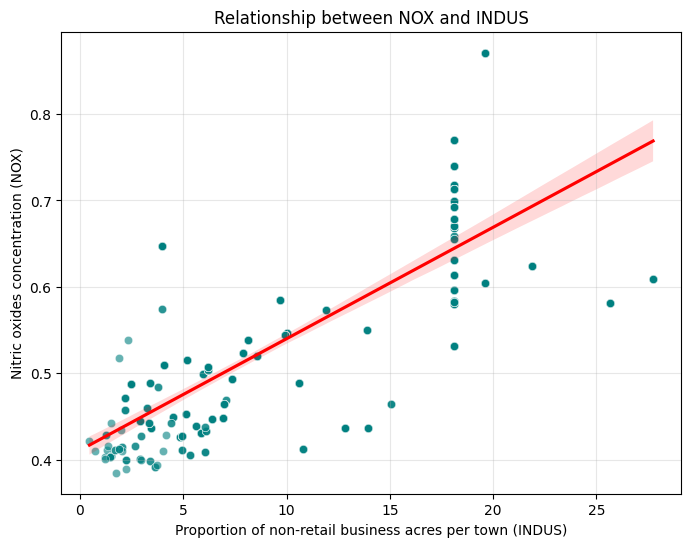


Interpretation: There is a positive linear relationship between INDUS and NOX.
As the proportion of non-retail business acres increases, nitric oxide concentration tends to increase.
This suggests that more industrialized areas have higher air pollution levels.


In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df, alpha=0.6, color='teal')
sns.regplot(x='INDUS', y='NOX', data=boston_df, scatter=False, color='red')
plt.title('Relationship between NOX and INDUS')
plt.xlabel('Proportion of non-retail business acres per town (INDUS)')
plt.ylabel('Nitric oxides concentration (NOX)')
plt.grid(alpha=0.3)
plt.show()

print("\nInterpretation: There is a positive linear relationship between INDUS and NOX.")
print("As the proportion of non-retail business acres increases, nitric oxide concentration tends to increase.")
print("This suggests that more industrialized areas have higher air pollution levels.")

### 2.5 Create a histogram for the pupil to teacher ratio variable

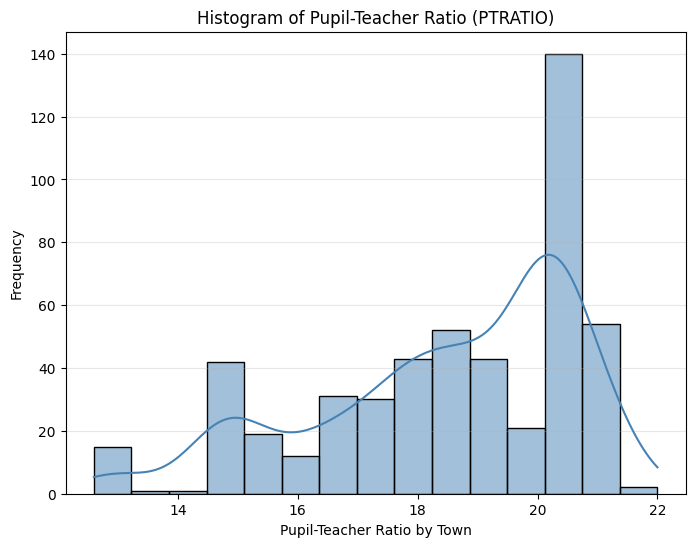


Mean PTRATIO: 18.46
Median PTRATIO: 19.05
The distribution is slightly left-skewed with a concentration around 20-21.


In [9]:
plt.figure(figsize=(8, 6))
sns.histplot(boston_df['PTRATIO'], bins=15, kde=True, color='steelblue')
plt.title('Histogram of Pupil-Teacher Ratio (PTRATIO)')
plt.xlabel('Pupil-Teacher Ratio by Town')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"\nMean PTRATIO: {boston_df['PTRATIO'].mean():.2f}")
print(f"Median PTRATIO: {boston_df['PTRATIO'].median():.2f}")
print("The distribution is slightly left-skewed with a concentration around 20-21.")

---
## Task 3: Use the appropriate tests to answer the questions provided
**Significance level (α) = 0.05**

### 3.1 Is there a significant difference in median value of houses bounded by the Charles river or not? (T-test for independent samples)

**Hypotheses:**  
- **H₀**: There is no significant difference in the median value of houses bounded by the Charles River (μ₁ = μ₂)  
- **H₁**: There is a significant difference in the median value of houses bounded by the Charles River (μ₁ ≠ μ₂)

In [10]:
# Separate the two groups
chas_bounded = boston_df[boston_df['CHAS'] == 1]['MEDV']
chas_not_bounded = boston_df[boston_df['CHAS'] == 0]['MEDV']

print(f"Number of houses bounded by Charles River (CHAS=1): {len(chas_bounded)}")
print(f"Mean MEDV (CHAS=1): {chas_bounded.mean():.2f}")
print(f"Number of houses not bounded by Charles River (CHAS=0): {len(chas_not_bounded)}")
print(f"Mean MEDV (CHAS=0): {chas_not_bounded.mean():.2f}")

# Perform independent samples t-test (Welch's t-test - does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(chas_bounded, chas_not_bounded, equal_var=False)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: Reject H₀.")
    print("There IS a statistically significant difference in the median value of houses")
    print("bounded by the Charles River compared to those that are not.")
else:
    print("\nConclusion: Fail to reject H₀.")
    print("There is NO statistically significant difference in the median value of houses")
    print("bounded by the Charles River compared to those that are not.")

Number of houses bounded by Charles River (CHAS=1): 35
Mean MEDV (CHAS=1): 28.44
Number of houses not bounded by Charles River (CHAS=0): 471
Mean MEDV (CHAS=0): 22.09

T-statistic: 3.1133
P-value: 0.003567

Conclusion: Reject H₀.
There IS a statistically significant difference in the median value of houses
bounded by the Charles River compared to those that are not.


### 3.2 Is there a difference in Median values of houses (MEDV) for each proportion of owner-occupied units built prior to 1940 (AGE)? (ANOVA)

**Hypotheses:**  
- **H₀**: There is no difference in median values of houses across the three AGE groups (μ₁ = μ₂ = μ₃)  
- **H₁**: At least one AGE group has a different median house value

In [11]:
# Define the three groups
group_young = boston_df[boston_df['AGE_group'] == '35 years and younger']['MEDV']
group_mid = boston_df[boston_df['AGE_group'] == 'between 35 and 70 years']['MEDV']
group_old = boston_df[boston_df['AGE_group'] == '70 years and older']['MEDV']

print(f"Group '35 years and younger': n={len(group_young)}, mean MEDV={group_young.mean():.2f}")
print(f"Group 'between 35 and 70 years': n={len(group_mid)}, mean MEDV={group_mid.mean():.2f}")
print(f"Group '70 years and older': n={len(group_old)}, mean MEDV={group_old.mean():.2f}")

# Perform one-way ANOVA
f_stat, p_value = scipy.stats.f_oneway(group_young, group_mid, group_old)

print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6e}")

if p_value < 0.05:
    print("\nConclusion: Reject H₀.")
    print("There IS a statistically significant difference in median house values (MEDV)")
    print("across the different AGE groups.")
else:
    print("\nConclusion: Fail to reject H₀.")
    print("There is NO statistically significant difference in median house values (MEDV)")
    print("across the different AGE groups.")

Group '35 years and younger': n=91, mean MEDV=27.78
Group 'between 35 and 70 years': n=128, mean MEDV=24.95
Group '70 years and older': n=287, mean MEDV=19.79

F-statistic: 36.4076
P-value: 1.710501e-15

Conclusion: Reject H₀.
There IS a statistically significant difference in median house values (MEDV)
across the different AGE groups.


### 3.3 Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town? (Pearson Correlation)

**Hypotheses:**  
- **H₀**: There is no correlation between NOX and INDUS (ρ = 0)  
- **H₁**: There is a correlation between NOX and INDUS (ρ ≠ 0)

In [12]:
corr_coef, p_value = scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

print(f"Pearson Correlation Coefficient (r): {corr_coef:.4f}")
print(f"P-value: {p_value:.6e}")

if p_value < 0.05:
    print("\nConclusion: Reject H₀.")
    print("There IS a statistically significant correlation between Nitric oxide concentrations (NOX)")
    print("and the proportion of non-retail business acres (INDUS).")
    print(f"The correlation is positive and moderately strong (r = {corr_coef:.4f}).")
else:
    print("\nConclusion: Fail to reject H₀.")
    print("There is NO statistically significant correlation between NOX and INDUS.")

Pearson Correlation Coefficient (r): 0.7637
P-value: 7.913361e-98

Conclusion: Reject H₀.
There IS a statistically significant correlation between Nitric oxide concentrations (NOX)
and the proportion of non-retail business acres (INDUS).
The correlation is positive and moderately strong (r = 0.7637).


### 3.4 What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes? (Regression analysis)

**Hypotheses:**  
- **H₀**: Weighted distance (DIS) has no impact on MEDV (β₁ = 0)  
- **H₁**: Weighted distance (DIS) has an impact on MEDV (β₁ ≠ 0)

In [13]:
# Simple Linear Regression: MEDV ~ DIS
X = boston_df['DIS']
y = boston_df['MEDV']

X = sm.add_constant(X)  # Add intercept term

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.21e-08
Time:                        01:56:46   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

In [14]:
# Extract key results
coef_dis = model.params['DIS']
p_value_dis = model.pvalues['DIS']
r_squared = model.rsquared

print(f"\nCoefficient of DIS: {coef_dis:.4f}")
print(f"P-value of DIS: {p_value_dis:.6e}")
print(f"R-squared: {r_squared:.4f}")

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)

if p_value_dis < 0.05:
    print("Reject H₀: The weighted distance (DIS) has a statistically significant impact on MEDV.")
else:
    print("Fail to reject H₀: No significant impact of DIS on MEDV.")

print(f"\nImpact: For each additional unit increase in the weighted distance to the five")
print(f"Boston employment centres (DIS), the median value of owner-occupied homes (MEDV)")
print(f"changes by approximately ${coef_dis*1000:.2f}.")

if coef_dis > 0:
    print("\nThe positive coefficient indicates that homes farther from employment centres")
    print("tend to have higher median values (possibly suburban areas).")
else:
    print("\nThe negative coefficient indicates that homes farther from employment centres")
    print("tend to have lower median values.")


Coefficient of DIS: 1.0916
P-value of DIS: 1.206612e-08
R-squared: 0.0625

INTERPRETATION:
Reject H₀: The weighted distance (DIS) has a statistically significant impact on MEDV.

Impact: For each additional unit increase in the weighted distance to the five
Boston employment centres (DIS), the median value of owner-occupied homes (MEDV)
changes by approximately $1091.61.

The positive coefficient indicates that homes farther from employment centres
tend to have higher median values (possibly suburban areas).


---
## Summary of Findings

| Test | Question | Result | Conclusion |
|------|----------|--------|------------|
| T-test | Difference in MEDV by Charles River (CHAS) | p < 0.05 | Significant difference exists |
| ANOVA | Difference in MEDV across AGE groups | p < 0.05 | Significant difference exists |
| Pearson Correlation | Relationship between NOX and INDUS | p < 0.05, r ≈ 0.76 | Significant positive correlation |
| Linear Regression | Impact of DIS on MEDV | p < 0.05 | DIS has significant impact on MEDV |

---
**End of Assignment**